# 1.4 — Data Cleaning of a Perturbed Dataset (Wine Quality)

**Goal.** `wine-quality/modified.csv` is a deliberately corrupted copy of the UCI *Wine Quality* (white wine) dataset
stored in `wine-quality/original.csv`. We will clean `modified.csv` using standard MLOps data-cleaning practice and then
show, with the same EDA used in notebook 1.3, that the cleaned data tells the same story as the original.

**Ground rule (very important).** In a real project there is no "original" file to compare against: the clean truth is
unknown. Therefore:

- Every cleaning decision below is driven **only** by tests run on `modified.csv` plus *domain knowledge* written down as a
  data contract **before** looking at the reference.
- The reference files are loaded **only at the end**: `original.csv` for a cell-level *audit* of the cleaning (Section 7),
  and `original_no_duplicates.csv` as the **baseline** for the comparative EDA (Section 8).

**Prerequisite.** Run `1.3_WineData_EDA_Example.ipynb` first: it removes the duplicate rows of `original.csv` and
generates `wine-quality/original_no_duplicates.csv`, the baseline used here.

**Structure of the notebook**

| Part | What happens |
|---|---|
| 1. Setup | Libraries, paths, plotting style |
| 2. Load raw data safely | Read everything as text so nothing is silently coerced |
| 3. Diagnostic tests | One test per data-quality problem; each test tells us *which* cleanup action is required |
| 4. Cleaning pipeline | One function per cleanup step, each explained |
| 5. Two strategies for bad cells | **A**: drop incomplete rows · **B**: impute features with the median |
| 6. Post-cleaning validation | Assertions that the data contract now holds |
| 7. Audit vs. the original | Cell-level recovery (only possible because this is a synthetic exercise) |
| 8. Comparative EDA | Same EDA as notebook 1.3, run on the deduplicated original (baseline) vs. Clean A vs. Clean B |
| 9. Conclusions | Which strategy preserves the distributions better, and why |

This notebook was developed with support of Anthropic's Claude Opus 5.5

# 1. Setup

In [48]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# Relative paths: this notebook lives next to the `wine-quality/` folder
DATA_DIR = Path("wine-quality")
MODIFIED_PATH = DATA_DIR / "modified.csv"
ORIGINAL_PATH = DATA_DIR / "original.csv"      # used ONLY in the audit section (Section 7)
BASELINE_PATH = DATA_DIR / "original_no_duplicates.csv"  # generated by notebook 1.3; used ONLY in Section 8
CLEAN_A_PATH = DATA_DIR / "cleaned_dropna.csv"  # output of strategy A
CLEAN_B_PATH = DATA_DIR / "cleaned_imputed.csv" # output of strategy B

# 2. Load the raw data safely

**Why read everything as text (`dtype=str`)?**
If we let pandas infer types, a single bad token such as `"?"` turns a whole numeric column into `object`, or worse,
a custom `na_values` list could silently hide problems we want to *see*. Loading as text first gives us full control:
we inspect, then convert explicitly. This mirrors the MLOps principle of **"never trust the input, validate it"**.

`keep_default_na=False` makes sure that even strings like `"NaN"` or `"null"` arrive as literal text, so our tests count them.

In [49]:
raw_df = pd.read_csv(MODIFIED_PATH, dtype=str, keep_default_na=False)

print(f"Rows: {raw_df.shape[0]:,}   Columns: {raw_df.shape[1]}")
raw_df.head()

Rows: 4,995   Columns: 13


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,mixed_type_col
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6.0,887
1,6.3,0.3,0.34,1.6,0.049,14.0,132.0,0.994,3.3,0.49,9.5,6.0,unknown
2,8.1,0.28,0.4,6.9,0.05,30.0,97.0,0.9951,3.26,0.44,10.1,6.0,unknown
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.4,9.9,6.0,461
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.4,9.9,6.0,207


In [50]:
# Metadata published with the perturbation (for reference only: in real life you rarely get this)
metadata = json.loads((DATA_DIR / "metadata.json").read_text())
metadata["rates"]

{'dup_rate': 0.02,
 'nan_rate': 0.01,
 'outlier_rate': 0.01,
 'bad_token_rate': 0.005,
 'obj_noise_rate': 0.05,
 'add_mixed_type': True}

# 3. Diagnostic tests

Before changing anything we **measure**. Each test below answers one question and maps to one cleanup action:

| # | Test | If it fails → required action |
|---|---|---|
| T1 | Schema test: columns match the data contract? | Drop unexpected columns / stop if required ones are missing |
| T2 | Type test: can every value be parsed as a number? | Normalize and cast types |
| T3 | Whitespace test: values with leading/trailing spaces? | Strip whitespace |
| T4 | Placeholder-token test: which non-numeric strings exist? | Map placeholders (`?`, `n/a`, `error`…) to missing |
| T5 | Missing-value test: how many empty cells per column? | Decide drop vs. impute |
| T6 | Domain-range test: values outside physically plausible bounds? | Treat as invalid (set to missing) |
| T7 | Cross-field consistency test: free SO₂ ≤ total SO₂? | Treat both values as invalid |
| T8 | Target test: is `quality` an integer in 0–10? | Drop rows with invalid target (never impute a label) |
| T9 | Duplicate test: exact duplicate rows? | Drop duplicates **after** normalization |

## The data contract
A *data contract* (schema + expectations) is the written agreement of what valid data looks like. Tools such as
**pandera** or **Great Expectations** formalize this; here we write it as a plain dictionary so every rule is visible.

The bounds come from oenology / lab-measurement knowledge and the dataset documentation (`winequality.names`), and are
deliberately **generous**: they are meant to catch impossible values (e.g. a pH of 700), not unusual-but-real wines.
They were **not** derived from `original.csv`.

In [51]:
# Data contract: expected columns, their meaning, and physically plausible bounds (inclusive)
DATA_CONTRACT = {
    #  column                  (min,   max)    units / rationale
    "fixed acidity":        (3.0,   16.0),  # g(tartaric acid)/L
    "volatile acidity":     (0.05,  1.6),   # g(acetic acid)/L; above ~1.2 wine is vinegar-like
    "citric acid":          (0.0,   1.7),   # g/L, cannot be negative
    "residual sugar":       (0.0,   70.0),  # g/L, even sweet table wines rarely exceed this
    "chlorides":            (0.005, 0.7),   # g(sodium chloride)/L
    "free sulfur dioxide":  (1.0,   300.0), # mg/L
    "total sulfur dioxide": (5.0,   450.0), # mg/L, legal limits are well below this
    "density":              (0.985, 1.04),  # g/cm^3, wine is close to water
    "pH":                   (2.7,   4.0),   # wine is acidic
    "sulphates":            (0.2,   2.0),   # g(potassium sulphate)/L
    "alcohol":              (8.0,   15.5),  # % vol for still table wine
    "quality":              (0,     10),    # sensory score, integer 0-10 (target)
}
EXPECTED_COLUMNS = list(DATA_CONTRACT)
TARGET = "quality"
FEATURES = [c for c in EXPECTED_COLUMNS if c != TARGET]

### T1 — Schema test
**What it checks:** the set of columns in the file vs. the contract.
**Why it matters:** an extra column can leak noise (or even the target) into a model; a missing column breaks the pipeline.

In [52]:
extra_cols = [c for c in raw_df.columns if c not in EXPECTED_COLUMNS]
missing_cols = [c for c in EXPECTED_COLUMNS if c not in raw_df.columns]

print("Unexpected columns:", extra_cols)
print("Missing columns:   ", missing_cols)

Unexpected columns: ['mixed_type_col']
Missing columns:    []


In [53]:
# Inspect the unexpected column before deciding what to do with it
for col in extra_cols:
    s = raw_df[col]
    as_num = pd.to_numeric(s.str.strip(), errors="coerce")
    print(f"--- {col} ---")
    print(f"Distinct values: {s.nunique():,}")
    print(f"Share parseable as number: {as_num.notna().mean():.1%}")
    print("Most frequent values:")
    print(s.value_counts().head(8).to_string())
    # Does it carry any signal about the target?
    q = pd.to_numeric(raw_df[TARGET].str.strip(), errors="coerce")
    print(f"Spearman corr. with quality (numeric part): {as_num.corr(q, method='spearman'):.3f}")

--- mixed_type_col ---
Distinct values: 966
Share parseable as number: 69.8%
Most frequent values:
mixed_type_col
unknown    529
bad        494
           487
381         11
225         10
993         10
27           9
261          9
Spearman corr. with quality (numeric part): -0.010


**Result → action.** `mixed_type_col` is not in the contract, mixes integers with text (`unknown`, `bad`) and has no
relationship with `quality`. It is a *mixed-type noise column* → **drop it**.

### T2 — Type test
**What it checks:** the share of values in each expected column that can be parsed as a number *as they are*.
**Why it matters:** every feature in the contract is numeric; anything that does not parse is either formatting noise or a real problem.

In [54]:
def parse_rate(series):
    return pd.to_numeric(series, errors="coerce").notna().mean()

type_test = pd.DataFrame({
    "parseable_as_is": raw_df[EXPECTED_COLUMNS].apply(parse_rate),
    "parseable_after_strip": raw_df[EXPECTED_COLUMNS].apply(lambda s: parse_rate(s.str.strip())),
})
type_test.style.format("{:.2%}")

,parseable_as_is,parseable_after_strip
fixed acidity,98.40%,98.40%
volatile acidity,98.50%,98.50%
citric acid,98.76%,98.76%
residual sugar,98.64%,98.64%
chlorides,98.54%,98.54%
free sulfur dioxide,98.56%,98.56%
total sulfur dioxide,98.34%,98.34%
density,98.58%,98.58%
pH,98.48%,98.48%
sulphates,98.60%,98.60%


**Result → action.** Every column fails as-is and improves after stripping spaces, so part of the problem is formatting (T3).
The remainder is non-numeric tokens or empty cells (T4, T5). Numeric **casting** must happen *after* those fixes.

### T3 — Whitespace test
**What it checks:** values whose text differs from their stripped version (e.g. `" 0.27 "`).
**Why it matters:** `" 0.27 "` and `"0.27"` are the same measurement but are different strings: they break parsing,
grouping and duplicate detection.

In [55]:
whitespace_counts = raw_df[EXPECTED_COLUMNS].apply(lambda s: (s != s.str.strip()).sum())
print(f"Cells with leading/trailing whitespace: {whitespace_counts.sum():,} "
      f"({whitespace_counts.sum() / raw_df[EXPECTED_COLUMNS].size:.1%} of all cells)")
whitespace_counts.to_frame("n_cells_with_whitespace")

Cells with leading/trailing whitespace: 3,013 (5.0% of all cells)


,n_cells_with_whitespace
fixed acidity,255
volatile acidity,242
citric acid,248
residual sugar,246
chlorides,268
free sulfur dioxide,251
total sulfur dioxide,249
density,249
pH,228
sulphates,256


**Result → action.** About 5% of cells are padded → **strip whitespace** in every column.

### T4 — Placeholder-token test
**What it checks:** after stripping, which non-empty strings still cannot be parsed as numbers.
**Why it matters:** upstream systems often write placeholders (`?`, `n/a`, `null`, `error`…) instead of leaving a cell empty.
We must list them explicitly rather than guess, so that a *new* unexpected token is noticed next time.

In [56]:
stripped = raw_df[EXPECTED_COLUMNS].apply(lambda s: s.str.strip())
not_numeric = stripped.apply(lambda s: s[(s != "") & pd.to_numeric(s, errors="coerce").isna()])

token_counts = (
    pd.Series(not_numeric.stack().values)
    .value_counts()
    .rename_axis("token").to_frame("count")
)
token_counts

,count
token,
NULL,72
invalid,57
?,56
error,55
N/A,49
NAN,30
n/a,5
null,2
ERROR,1


In [57]:
# Placeholders are compared case-insensitively
PLACEHOLDER_TOKENS = {t.lower() for t in token_counts.index}
print("Tokens that will be treated as missing:", sorted(PLACEHOLDER_TOKENS))

Tokens that will be treated as missing: ['?', 'error', 'invalid', 'n/a', 'nan', 'null']


**Result → action.** A small, well-defined set of placeholder strings → **map them to missing (NaN)**, then cast to float.

### T5 — Missing-value test
**What it checks:** empty cells per column, *before* and *after* placeholders are converted.
**Why it matters:** the amount and pattern of missingness decides whether dropping rows is affordable or imputation is needed.

In [58]:
empty_cells = (stripped == "").sum()
after_tokens = stripped.apply(lambda s: pd.to_numeric(s, errors="coerce")).isna().sum()

missing_test = pd.DataFrame({
    "empty_cells": empty_cells,
    "missing_incl_placeholders": after_tokens,
    "missing_pct": after_tokens / len(stripped) * 100,
})
print(f"Rows with at least one missing value: "
      f"{stripped.apply(lambda s: pd.to_numeric(s, errors='coerce')).isna().any(axis=1).sum():,}")
missing_test

Rows with at least one missing value: 804


,empty_cells,missing_incl_placeholders,missing_pct
fixed acidity,48,80,1.601602
volatile acidity,48,75,1.501502
citric acid,36,62,1.241241
residual sugar,44,68,1.361361
chlorides,42,73,1.461461
free sulfur dioxide,47,72,1.441441
total sulfur dioxide,55,83,1.661662
density,51,71,1.421421
pH,49,76,1.521522
sulphates,41,70,1.401401


**Result → action.** Roughly 1–2% per column, spread across different rows. Individually small, but combined they
touch a much larger share of rows. That is exactly why we will compare two strategies (Part 5).

### T6 — Domain-range test
**What it checks:** parsed values outside the bounds of the data contract.
**Why it matters:** values like `pH = 700` or `alcohol = 987 %` are physically impossible. They are **errors**, not outliers,
and even a handful of them destroys means, standard deviations and correlations.

> **Error vs. outlier.** The IQR rule used in notebook 1.3 flags *statistically unusual* values, many of which are real wines
> (skewed variables such as `chlorides` naturally have long tails). A domain rule flags *impossible* values.
> Only the latter should be removed automatically.

In [59]:
numeric_raw = stripped.apply(lambda s: pd.to_numeric(s, errors="coerce"))

range_rows = []
for col, (lo, hi) in DATA_CONTRACT.items():
    s = numeric_raw[col]
    bad = (s < lo) | (s > hi)
    range_rows.append({
        "feature": col, "contract_min": lo, "contract_max": hi,
        "observed_min": s.min(), "observed_max": s.max(),
        "n_out_of_range": int(bad.sum()),
        "examples": s[bad].head(3).round(3).tolist(),
    })
range_test = pd.DataFrame(range_rows).set_index("feature")
print(f"Out-of-range cells: {range_test['n_out_of_range'].sum():,}")
range_test

Out-of-range cells: 567


,contract_min,contract_max,observed_min,observed_max,n_out_of_range,examples
feature,,,,,,
fixed acidity,3.000,16.00,3.80000,28380.8000,39,"[470.1, 787.3, 409.6]"
volatile acidity,0.050,1.60,0.08000,950.1200,51,"[7.56, 6.0, 9.02]"
citric acid,0.000,1.70,0.00000,999.4900,49,"[530.5, 9.84, 289.56]"
residual sugar,0.000,70.00,0.60000,1548.4000,57,"[164.4, 276.4, 325.5]"
chlorides,0.005,0.70,0.00900,972.0600,55,"[2.0, 664.046, 551.346]"
free sulfur dioxide,1.000,300.00,2.00000,5742.0000,49,"[1054.0, 676.0, 462.0]"
total sulfur dioxide,5.000,450.00,9.00000,18954.0000,32,"[1045.0, 8034.0, 9945.0]"
density,0.985,1.04,0.98711,942.9914,48,"[40.754, 412.997, 80.08]"
pH,2.700,4.00,2.72000,916.4400,45,"[700.18, 215.82, 255.84]"


In [60]:
# Why not simply use the IQR rule? Compare how many cells each rule would flag.
iqr_flags = {}
for col in FEATURES:
    s = numeric_raw[col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    iqr_flags[col] = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())

pd.DataFrame({
    "domain_rule_flags": range_test.loc[FEATURES, "n_out_of_range"],
    "iqr_1.5_flags": pd.Series(iqr_flags),
})

,domain_rule_flags,iqr_1.5_flags
fixed acidity,39,118
volatile acidity,51,194
citric acid,49,318
residual sugar,57,68
chlorides,55,261
free sulfur dioxide,49,104
total sulfur dioxide,32,54
density,48,53
pH,45,117
sulphates,52,178


**Result → action.** Every column has impossible values, often 10–1000× the normal scale → **set them to missing** and
handle them together with the other missing values. The IQR rule would flag far more cells (mostly genuine tail values in
skewed variables), so it is kept as a *diagnostic* only, exactly as in notebook 1.3.

### T7 — Cross-field consistency test
**What it checks:** a chemical invariant: *free* SO₂ is a part of *total* SO₂, so `free sulfur dioxide ≤ total sulfur dioxide`.
**Why it matters:** single-column range checks cannot catch a value that is plausible on its own but inconsistent with
another column. Multi-column rules catch part of the corruption that stays inside the valid range.

In [61]:
free_so2, total_so2 = numeric_raw["free sulfur dioxide"], numeric_raw["total sulfur dioxide"]
so2_violation_all = free_so2 > total_so2

# Most violations are caused by impossible values already caught by T6. The interesting ones are the rows
# where BOTH values pass the range test and are still inconsistent: only a multi-column rule can find those.
in_range = (free_so2.between(*DATA_CONTRACT["free sulfur dioxide"])
            & total_so2.between(*DATA_CONTRACT["total sulfur dioxide"]))
so2_violation = so2_violation_all & in_range

print(f"Rows violating free SO2 <= total SO2 (any value):          {so2_violation_all.sum()}")
print(f"... of which both values pass the domain-range test (T6): {so2_violation.sum()}")
numeric_raw.loc[so2_violation, ["free sulfur dioxide", "total sulfur dioxide"]]

Rows violating free SO2 <= total SO2 (any value):          51
... of which both values pass the domain-range test (T6): 3


,free sulfur dioxide,total sulfur dioxide
805,190.0,161.0
1364,283.0,143.0
3704,210.0,180.0


**Result → action.** We cannot know which of the two values is wrong → **set both to missing** for those rows.

### T8 — Target test
**What it checks:** `quality` must be an integer between 0 and 10.
**Why it matters:** the target is the ground truth the model learns from. **Never impute a label**: a guessed label is a
fabricated training example. Rows with an invalid target are dropped in both strategies.

In [62]:
q = numeric_raw[TARGET]
target_test = pd.Series({
    "missing / unparseable": int(q.isna().sum()),
    "non-integer": int((q.dropna() % 1 != 0).sum()),
    "outside 0-10": int(((q < 0) | (q > 10)).sum()),
})
print(target_test.to_string())
print("\nValid label values present:", sorted(q[(q >= 0) & (q <= 10)].dropna().unique()))

missing / unparseable    78
non-integer               0
outside 0-10             50

Valid label values present: [np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]


**Result → action.** Labels are stored as floats (`6.0`) and some are missing or impossible → **drop those rows and cast `quality` to integer**.

### T9 — Duplicate test
**What it checks:** exact duplicate rows, before and after normalization.
**Why it matters:** duplicates over-weight some observations, bias statistics, and can leak between train and test splits.
Formatting noise *hides* duplicates, so deduplication must run **after** normalization.

In [63]:
dups_raw = raw_df.duplicated().sum()
dups_expected_cols = raw_df[EXPECTED_COLUMNS].duplicated().sum()
dups_normalized = numeric_raw.duplicated().sum()

pd.Series({
    "exact duplicates in raw file": dups_raw,
    "... ignoring the noise column": dups_expected_cols,
    "... after stripping and parsing": dups_normalized,
}).to_frame("n_duplicate_rows")

,n_duplicate_rows
exact duplicates in raw file,13
... ignoring the noise column,205
... after stripping and parsing,614


**Result → action.** The count grows at each normalization step, which shows that noise was hiding duplicates →
**drop exact duplicates as the last cleaning step**.

# 4. Cleaning pipeline

Each test above maps to one small, **pure function** (input DataFrame → new DataFrame, no hidden state). This is the
MLOps way of writing cleaning code: every step is testable on its own, the order is explicit, and the same pipeline can be
re-run on next month's data or moved into a production job unchanged.

We also keep a **cleaning log** that records how many cells/rows each step touched. In production this log would be
stored with the dataset version (e.g. with DVC or MLflow) for traceability.

In [64]:
cleaning_log = []

def log_step(step, detail, rows_before, rows_after, cells_changed=None):
    cleaning_log.append({
        "step": step, "detail": detail,
        "rows_before": rows_before, "rows_after": rows_after,
        "cells_changed": cells_changed,
    })


def enforce_schema(df):
    # Step 1 (from T1): keep only contract columns, in contract order
    dropped = [c for c in df.columns if c not in EXPECTED_COLUMNS]
    missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")   # fail loudly, never guess
    log_step("enforce_schema", f"dropped {dropped}", len(df), len(df))
    return df[EXPECTED_COLUMNS].copy()


def strip_whitespace(df):
    # Step 2 (from T3): remove leading/trailing spaces from every text cell
    out = df.apply(lambda s: s.str.strip())
    log_step("strip_whitespace", "str.strip() on all columns", len(df), len(out),
             int((out != df).sum().sum()))
    return out


def placeholders_to_nan(df, tokens):
    # Step 3 (from T4/T5): known placeholders and empty strings -> NaN
    is_placeholder = df.apply(lambda s: s.str.lower().isin(tokens) | (s == ""))
    out = df.mask(is_placeholder)
    log_step("placeholders_to_nan", f"{len(tokens)} tokens + empty strings", len(df), len(out),
             int(is_placeholder.sum().sum()))
    return out


def cast_numeric(df):
    # Step 4 (from T2): explicit cast; anything still unparseable becomes NaN and is counted
    out = df.apply(lambda s: pd.to_numeric(s, errors="coerce"))
    newly_nan = int((out.isna() & df.notna()).sum().sum())
    log_step("cast_numeric", "to float64 (unparseable -> NaN)", len(df), len(out), newly_nan)
    return out


def invalidate_out_of_range(df, contract):
    # Step 5 (from T6): impossible values are errors -> NaN (decided later: drop or impute)
    out = df.copy()
    n = 0
    for col, (lo, hi) in contract.items():
        bad = (out[col] < lo) | (out[col] > hi)
        n += int(bad.sum())
        out.loc[bad, col] = np.nan
    log_step("invalidate_out_of_range", "values outside data-contract bounds -> NaN", len(df), len(out), n)
    return out


def invalidate_inconsistent_so2(df):
    # Step 6 (from T7): free SO2 cannot exceed total SO2 -> both unknown
    out = df.copy()
    bad = out["free sulfur dioxide"] > out["total sulfur dioxide"]
    out.loc[bad, ["free sulfur dioxide", "total sulfur dioxide"]] = np.nan
    log_step("invalidate_inconsistent_so2", "free SO2 > total SO2 -> both NaN", len(df), len(out), int(bad.sum()) * 2)
    return out


def drop_invalid_target(df):
    # Step 7 (from T8): a label is never imputed; also enforce integer dtype
    valid = df[TARGET].notna() & (df[TARGET] % 1 == 0)
    out = df[valid].copy()
    out[TARGET] = out[TARGET].astype(int)
    log_step("drop_invalid_target", "rows with missing/invalid quality removed", len(df), len(out))
    return out


def drop_duplicates(df):
    # Step 9 (from T9): last step, once formatting noise can no longer hide duplicates
    out = df.drop_duplicates().copy()
    log_step("drop_duplicates", "exact duplicate rows removed", len(df), len(out))
    return out

### Steps 1–7: shared by both strategies

In [65]:
base_df = (
    raw_df
    .pipe(enforce_schema)
    .pipe(strip_whitespace)
    .pipe(placeholders_to_nan, PLACEHOLDER_TOKENS)
    .pipe(cast_numeric)
    .pipe(invalidate_out_of_range, DATA_CONTRACT)
    .pipe(invalidate_inconsistent_so2)
    .pipe(drop_invalid_target)
)

n_rows_with_nan = base_df[FEATURES].isna().any(axis=1).sum()
print(f"Rows after shared steps: {len(base_df):,}")
print(f"Rows with at least one missing feature: {n_rows_with_nan:,} ({n_rows_with_nan / len(base_df):.1%})")
base_df[FEATURES].isna().sum().to_frame("missing_cells")

Rows after shared steps: 4,867
Rows with at least one missing feature: 1,129 (23.2%)


,missing_cells
fixed acidity,116
volatile acidity,123
citric acid,110
residual sugar,124
chlorides,123
free sulfur dioxide,118
total sulfur dioxide,113
density,117
pH,118
sulphates,122


# 5. Two strategies for the remaining missing feature values

At this point every problem has been converted into a single, well-understood one: **missing feature values**.
There are two standard ways to handle them:

| | Strategy A — **drop incomplete rows** (listwise deletion) | Strategy B — **median imputation** |
|---|---|---|
| Idea | Keep only rows where every feature is valid | Replace each missing value by the column median |
| Pros | Every remaining value is a real measurement; distributions and correlations are not distorted | Keeps many more rows |
| Cons | Loses every row with *any* bad cell (here about a quarter of the data) | Creates artificial spikes at the median, shrinks the spread, weakens correlations, and can break multi-column rules (re-checked below) |
| Valid when | Missingness is random (MCAR) and enough rows remain | Missingness is low and the model needs every row |

> **MLOps note on leakage.** In a modelling pipeline, the imputation median must be *fitted on the training split only*
> (e.g. `sklearn.impute.SimpleImputer` inside a `Pipeline`) and then applied to the test split. Here we impute the whole
> dataset because the goal is data cleaning for EDA, not model evaluation.

Step 8 differs per strategy; step 9 (deduplication) runs in both, **after** step 8.

In [66]:
def strategy_a_drop_rows(df):
    # Step 8A: listwise deletion
    out = df.dropna(subset=FEATURES).copy()
    log_step("A: drop_incomplete_rows", "rows with any missing feature removed", len(df), len(out))
    return out


def strategy_b_impute_median(df):
    # Step 8B: median imputation (robust to the skewed features seen in the EDA)
    out = df.copy()
    medians = out[FEATURES].median()
    n = int(out[FEATURES].isna().sum().sum())
    out[FEATURES] = out[FEATURES].fillna(medians)
    log_step("B: impute_median", "missing features <- column median", len(df), len(out), n)

    # Imputation is column-by-column, so it can break a multi-column rule: an imputed free SO2 median
    # may exceed a low (real) total SO2. Re-run the T7 check and drop the few rows that now violate it.
    consistent = out["free sulfur dioxide"] <= out["total sulfur dioxide"]
    log_step("B: recheck_so2_after_impute", "rows made inconsistent by imputation removed",
             len(out), int(consistent.sum()))
    return out[consistent].copy()


clean_a = base_df.pipe(strategy_a_drop_rows).pipe(drop_duplicates).reset_index(drop=True)
clean_b = base_df.pipe(strategy_b_impute_median).pipe(drop_duplicates).reset_index(drop=True)

print(f"Strategy A (drop rows):  {len(clean_a):,} rows")
print(f"Strategy B (impute):     {len(clean_b):,} rows")

Strategy A (drop rows):  3,126 rows
Strategy B (impute):     4,245 rows


In [67]:
# The cleaning log documents what every step did (step 9 appears once per strategy)
pd.DataFrame(cleaning_log)

,step,detail,rows_before,rows_after,cells_changed
0,enforce_schema,dropped ['mixed_type_col'],4995,4995,NaN
1,strip_whitespace,str.strip() on all columns,4995,4995,3013.0
2,placeholders_to_nan,6 tokens + empty strings,4995,4995,890.0
3,cast_numeric,to float64 (unparseable -> NaN),4995,4995,0.0
4,invalidate_out_of_range,values outside data-contract bounds -> NaN,4995,4995,567.0
5,invalidate_inconsistent_so2,free SO2 > total SO2 -> both NaN,4995,4995,6.0
6,drop_invalid_target,rows with missing/invalid quality removed,4995,4867,NaN
7,A: drop_incomplete_rows,rows with any missing feature removed,4867,3738,NaN
8,drop_duplicates,exact duplicate rows removed,3738,3126,NaN
9,B: impute_median,missing features <- column median,4867,4867,1301.0


# 6. Post-cleaning validation

Cleaning is not finished until we **prove** the output satisfies the data contract. These assertions would run
automatically in a CI pipeline or as a gate before training; if one fails, the pipeline stops.

In [68]:
def validate(df, name):
    assert list(df.columns) == EXPECTED_COLUMNS, "column set/order"
    assert df.notna().all().all(), "no missing values"
    assert all(pd.api.types.is_numeric_dtype(df[c]) for c in FEATURES), "numeric features"
    assert pd.api.types.is_integer_dtype(df[TARGET]), "integer target"
    for col, (lo, hi) in DATA_CONTRACT.items():
        assert df[col].between(lo, hi).all(), f"{col} within contract bounds"
    assert (df["free sulfur dioxide"] <= df["total sulfur dioxide"]).all(), "SO2 consistency"
    assert not df.duplicated().any(), "no duplicate rows"
    print(f"{name}: all {len(df):,} rows pass the data contract")

validate(clean_a, "Clean A (drop rows)")
validate(clean_b, "Clean B (impute)")

Clean A (drop rows): all 3,126 rows pass the data contract
Clean B (impute): all 4,245 rows pass the data contract


In [69]:
# Persist the cleaned datasets (versioned artefacts in a real project)
clean_a.to_csv(CLEAN_A_PATH, index=False)
clean_b.to_csv(CLEAN_B_PATH, index=False)
print("Saved:", CLEAN_A_PATH, "and", CLEAN_B_PATH)

Saved: wine-quality/cleaned_dropna.csv and wine-quality/cleaned_imputed.csv


# 7. Audit against the original (synthetic exercise only)

From here on we load `original.csv`. Nothing above depends on it.

Because the perturbation kept the first 4,898 rows of `modified.csv` aligned with `original.csv` and appended the injected
duplicates at the end, we can check, cell by cell, how many corrupted values the tests detected. First we verify that
assumption rather than trusting it.

In [70]:
original_df = pd.read_csv(ORIGINAL_PATH)
assert list(original_df.columns) == EXPECTED_COLUMNS

# Parse the modified file with only formatting fixes (no range rules) to compare cell values.
# The audit re-uses pipeline steps; save the cleaning log so the audit does not pollute it.
saved_log = list(cleaning_log)
parsed = (raw_df.pipe(enforce_schema).pipe(strip_whitespace)
          .pipe(placeholders_to_nan, PLACEHOLDER_TOKENS).pipe(cast_numeric))

aligned = parsed.iloc[: len(original_df)].reset_index(drop=True)
same = np.isclose(aligned.values, original_df.values, equal_nan=False)
# If rows were NOT aligned, almost no cells would match. A very high cell match rate confirms the alignment;
# the non-matching cells are exactly the injected corruption.
print(f"Cells identical to the original after formatting fixes: {same.mean():.1%}")
print(f"Rows identical in every column: {same.all(axis=1).mean():.1%}")

Cells identical to the original after formatting fixes: 97.5%
Rows identical in every column: 74.5%


In [71]:
# Ground truth of corruption per cell: value missing/unparseable OR different from the original
corrupted = ~same
parsed_flags = (
    parsed.pipe(invalidate_out_of_range, DATA_CONTRACT)
          .pipe(invalidate_inconsistent_so2)
          .iloc[: len(original_df)].reset_index(drop=True)
          .isna().values
)
cleaning_log[:] = saved_log  # restore the log of the real cleaning run

tp = int((parsed_flags & corrupted).sum())
fn = int((~parsed_flags & corrupted).sum())
fp = int((parsed_flags & ~corrupted).sum())
print(f"Corrupted cells in the aligned part: {corrupted.sum():,}")
print(f"Detected by the tests (true positives): {tp:,}  -> recall {tp / (tp + fn):.1%}")
print(f"Valid cells wrongly flagged (false positives): {fp:,}")
print(f"Undetected corrupted cells (false negatives): {fn:,}")

Corrupted cells in the aligned part: 1,452
Detected by the tests (true positives): 1,433  -> recall 98.7%
Valid cells wrongly flagged (false positives): 3
Undetected corrupted cells (false negatives): 19


In [72]:
# What did we miss? Values that were changed but still look plausible
missed = pd.DataFrame(~parsed_flags & corrupted, columns=EXPECTED_COLUMNS)
examples = []
for col in EXPECTED_COLUMNS:
    for i in missed.index[missed[col]]:
        examples.append({"feature": col, "modified": aligned.at[i, col], "original": original_df.at[i, col]})
pd.DataFrame(examples)

,feature,modified,original
0,citric acid,0.720,0.040
1,residual sugar,54.600,1.400
2,residual sugar,57.000,1.000
3,residual sugar,42.000,2.100
4,residual sugar,26.000,1.000
5,residual sugar,32.000,1.600
6,chlorides,0.336,0.028
7,free sulfur dioxide,176.000,32.000
8,free sulfur dioxide,168.000,36.000
9,total sulfur dioxide,216.000,75.000


**Reading the audit.** The tests catch about 99% of the corrupted cells. The only "false positives" come from the SO₂
consistency rule (T7): when one of the two values was corrupted, the rule also discards its valid partner, because it cannot know
which one was wrong. That is a deliberate, conservative choice. The few misses are values that were altered but stayed inside a plausible range
(e.g. a total SO₂ of 216 instead of 75). No rule based on a single row can detect those; they behave like ordinary
measurement noise and, as the next section shows, have a negligible effect on the distributions.

# 8. Comparative EDA

We now repeat the EDA of notebook 1.3 on three datasets side by side:

| Name | Description |
|---|---|
| **Original (dedup)** | **Baseline.** `original_no_duplicates.csv`, generated by notebook 1.3 (`original.csv` without its duplicate rows) |
| **Clean A — drop** | Strategy A output (`cleaned_dropna.csv`) |
| **Clean B — impute** | Strategy B output (`cleaned_imputed.csv`) |

**Why a deduplicated baseline?** We removed duplicates during cleaning, so the fair, apples-to-apples reference is the
original after the *same* rule. `original.csv` as published contains 937 genuine duplicate rows (about 19%); comparing
against it would mix two effects, our cleaning and the deduplication decision. Applying the same rule to both sides
isolates the effect of cleaning.

In [73]:
if not BASELINE_PATH.exists():
    raise FileNotFoundError(f"{BASELINE_PATH} not found: run notebook 1.3_WineData_EDA_Example.ipynb first")

original_dedup_df = pd.read_csv(BASELINE_PATH)
assert list(original_dedup_df.columns) == EXPECTED_COLUMNS
assert not original_dedup_df.duplicated().any(), "baseline must not contain duplicates"
print(f"Baseline: {BASELINE_PATH} ({len(original_dedup_df):,} rows)")

datasets = {
    "Original (dedup)": original_dedup_df,
    "Clean A - drop": clean_a,
    "Clean B - impute": clean_b,
}
REFERENCE = "Original (dedup)"
PALETTE = dict(zip(datasets, ["#4c72b0", "#55a868", "#dd8452"]))

numeric_features = FEATURES  # same name as in notebook 1.3

def long_format(cols):
    # Stack all datasets into one long DataFrame with a `dataset` column (handy for seaborn hue)
    return pd.concat([d[cols].assign(dataset=name) for name, d in datasets.items()], ignore_index=True)

Baseline: wine-quality/original_no_duplicates.csv (3,961 rows)


## 8.1 Dataset structure and data quality

In [74]:
structure = pd.DataFrame({
    name: {
        "rows": len(d),
        "columns": d.shape[1],
        "missing_cells": int(d.isna().sum().sum()),
        "duplicated_rows": int(d.duplicated().sum()),
        "duplicate_pct": 100 * d.duplicated().mean(),
    }
    for name, d in datasets.items()
}).T
structure

,rows,columns,missing_cells,duplicated_rows,duplicate_pct
Original (dedup),3961.0,12.0,0.0,0.0,0.0
Clean A - drop,3126.0,12.0,0.0,0.0,0.0
Clean B - impute,4245.0,12.0,0.0,0.0,0.0


The cleaned sets have no missing values or duplicates. Row counts differ by design: Strategy A trades rows for purity,
Strategy B keeps more rows but part of their values are imputed.

## 8.2 Target variable: `quality`

In [75]:
quality_pct = pd.DataFrame({
    name: d[TARGET].value_counts(normalize=True).sort_index() * 100
    for name, d in datasets.items()
}).fillna(0)
quality_pct.round(2)

,Original (dedup),Clean A - drop,Clean B - impute
quality,,,
3,0.50,0.45,0.45
4,3.86,3.61,3.65
5,29.66,29.11,29.92
6,45.14,45.39,45.18
7,17.39,17.91,17.34
8,3.31,3.36,3.35
9,0.13,0.16,0.12


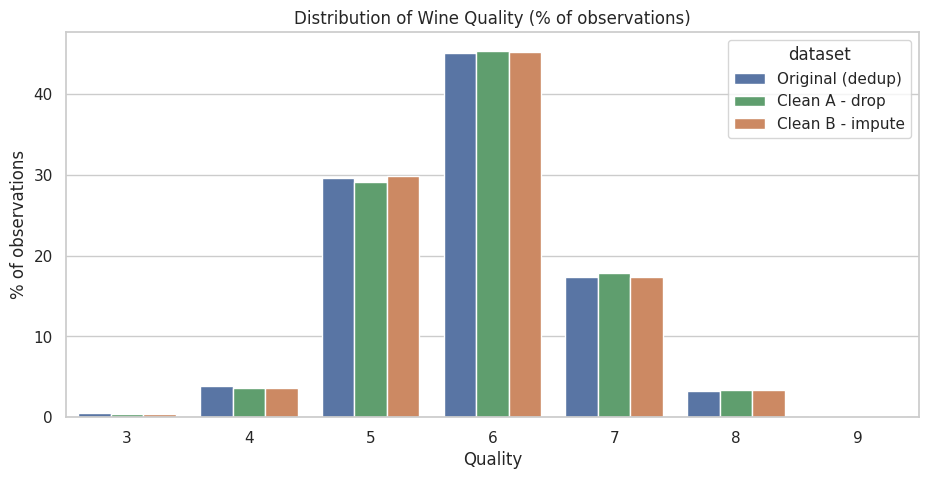

In [76]:
plot_df = quality_pct.reset_index(names="quality").melt(id_vars="quality", var_name="dataset", value_name="percentage")

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="quality", y="percentage", hue="dataset", palette=PALETTE)
plt.title("Distribution of Wine Quality (% of observations)")
plt.xlabel("Quality")
plt.ylabel("% of observations")
plt.show()

In [77]:
# Chi-square test of homogeneity: are the class proportions the same as the reference?
ref_counts = datasets[REFERENCE][TARGET].value_counts().sort_index()
for name in ["Clean A - drop", "Clean B - impute"]:
    counts = datasets[name][TARGET].value_counts().reindex(ref_counts.index, fill_value=0)
    chi2, p, _, _ = stats.chi2_contingency(np.vstack([ref_counts.values, counts.values]))
    print(f"{name:18s} vs {REFERENCE}: chi2 = {chi2:6.2f}, p-value = {p:.3f}")

Clean A - drop     vs Original (dedup): chi2 =   1.03, p-value = 0.984
Clean B - impute   vs Original (dedup): chi2 =   0.46, p-value = 0.998


A p-value above 0.05 means we find **no evidence** that the class proportions differ. The class imbalance seen in the
original (qualities 5–7 dominate; 3 and 9 are rare) is preserved by both strategies, because we only removed rows at random
positions, never based on the label value.

## 8.3 Univariate analysis

In [78]:
def univariate_summary(d):
    s = d[numeric_features]
    return pd.DataFrame({
        "mean": s.mean(), "median": s.median(), "std": s.std(),
        "min": s.min(), "max": s.max(),
        "skewness": s.skew(), "kurtosis": s.kurt(),
    })

univariate = pd.concat({name: univariate_summary(d) for name, d in datasets.items()}, axis=1)
univariate.xs("mean", axis=1, level=1).round(4)

,Original (dedup),Clean A - drop,Clean B - impute
fixed acidity,6.8393,6.8425,6.8453
volatile acidity,0.2805,0.2799,0.2795
citric acid,0.3343,0.3349,0.3337
residual sugar,5.9148,6.0945,6.1034
chlorides,0.0459,0.0459,0.0457
free sulfur dioxide,34.8892,34.9981,34.9528
total sulfur dioxide,137.1935,137.7927,138.3584
density,0.9938,0.9938,0.9939
pH,3.1955,3.1953,3.1919
sulphates,0.4904,0.4918,0.4898


In [79]:
# Relative difference (%) of each statistic vs the reference
rel_diff = {}
ref_stats = univariate_summary(datasets[REFERENCE])
for name in ["Clean A - drop", "Clean B - impute"]:
    s = univariate_summary(datasets[name])
    rel_diff[name] = ((s - ref_stats) / ref_stats.abs() * 100)[["mean", "median", "std", "skewness"]]

pd.concat(rel_diff, axis=1).round(1)

Clean A - drop                      Clean B - impute                     
                               mean median  std skewness             mean median  std skewness
fixed acidity                   0.0    0.0 -0.4      3.1              0.1    0.0 -2.1     -1.6
volatile acidity               -0.2    0.0 -2.8     -9.3             -0.4    0.0 -3.0     -6.4
citric acid                     0.2    0.0  1.0     11.2             -0.2    0.0 -1.0      1.8
residual sugar                  3.0    4.3  2.1     -2.9              3.2    8.5  3.6     29.6
chlorides                       0.0    2.4 -0.8     -1.6             -0.3    2.4 -3.2      1.5
free sulfur dioxide             0.3    0.0  0.3     17.2              0.2    3.0 -1.5      5.0
total sulfur dioxide            0.4    0.0  2.6     56.1              0.8    0.8  0.7     43.2
density                         0.0    0.0 -2.2    -72.7              0.0    0.0 -0.3     -3.8
pH                             -0.0    0.0 -0.5      2.8             -0.1    0.0 -1.9      3.9
sulphates                       0.3    0.0  1.4      6.2             -0.1   -2.1 -1.1      6.3
alcohol                        -0.1    0.0  0.9     -0.8             -0.3    0.0 -0.6      6.2

**How to read it.** Values are percentage differences against *Original (dedup)*. Means and medians of both cleaned sets
stay within a few percent. The column to watch is **`std`**: imputation (B) tends to *shrink* it, because every imputed
value sits exactly at the center of the distribution. The skewness is the most sensitive
statistic, because it depends heavily on a few extreme (but valid) values. For example, the skewness of `density` changes
a lot in Strategy A simply because the single densest wine (1.039, a very sweet sample) happened to be in a dropped row, while the bulk
of the distribution is unchanged.

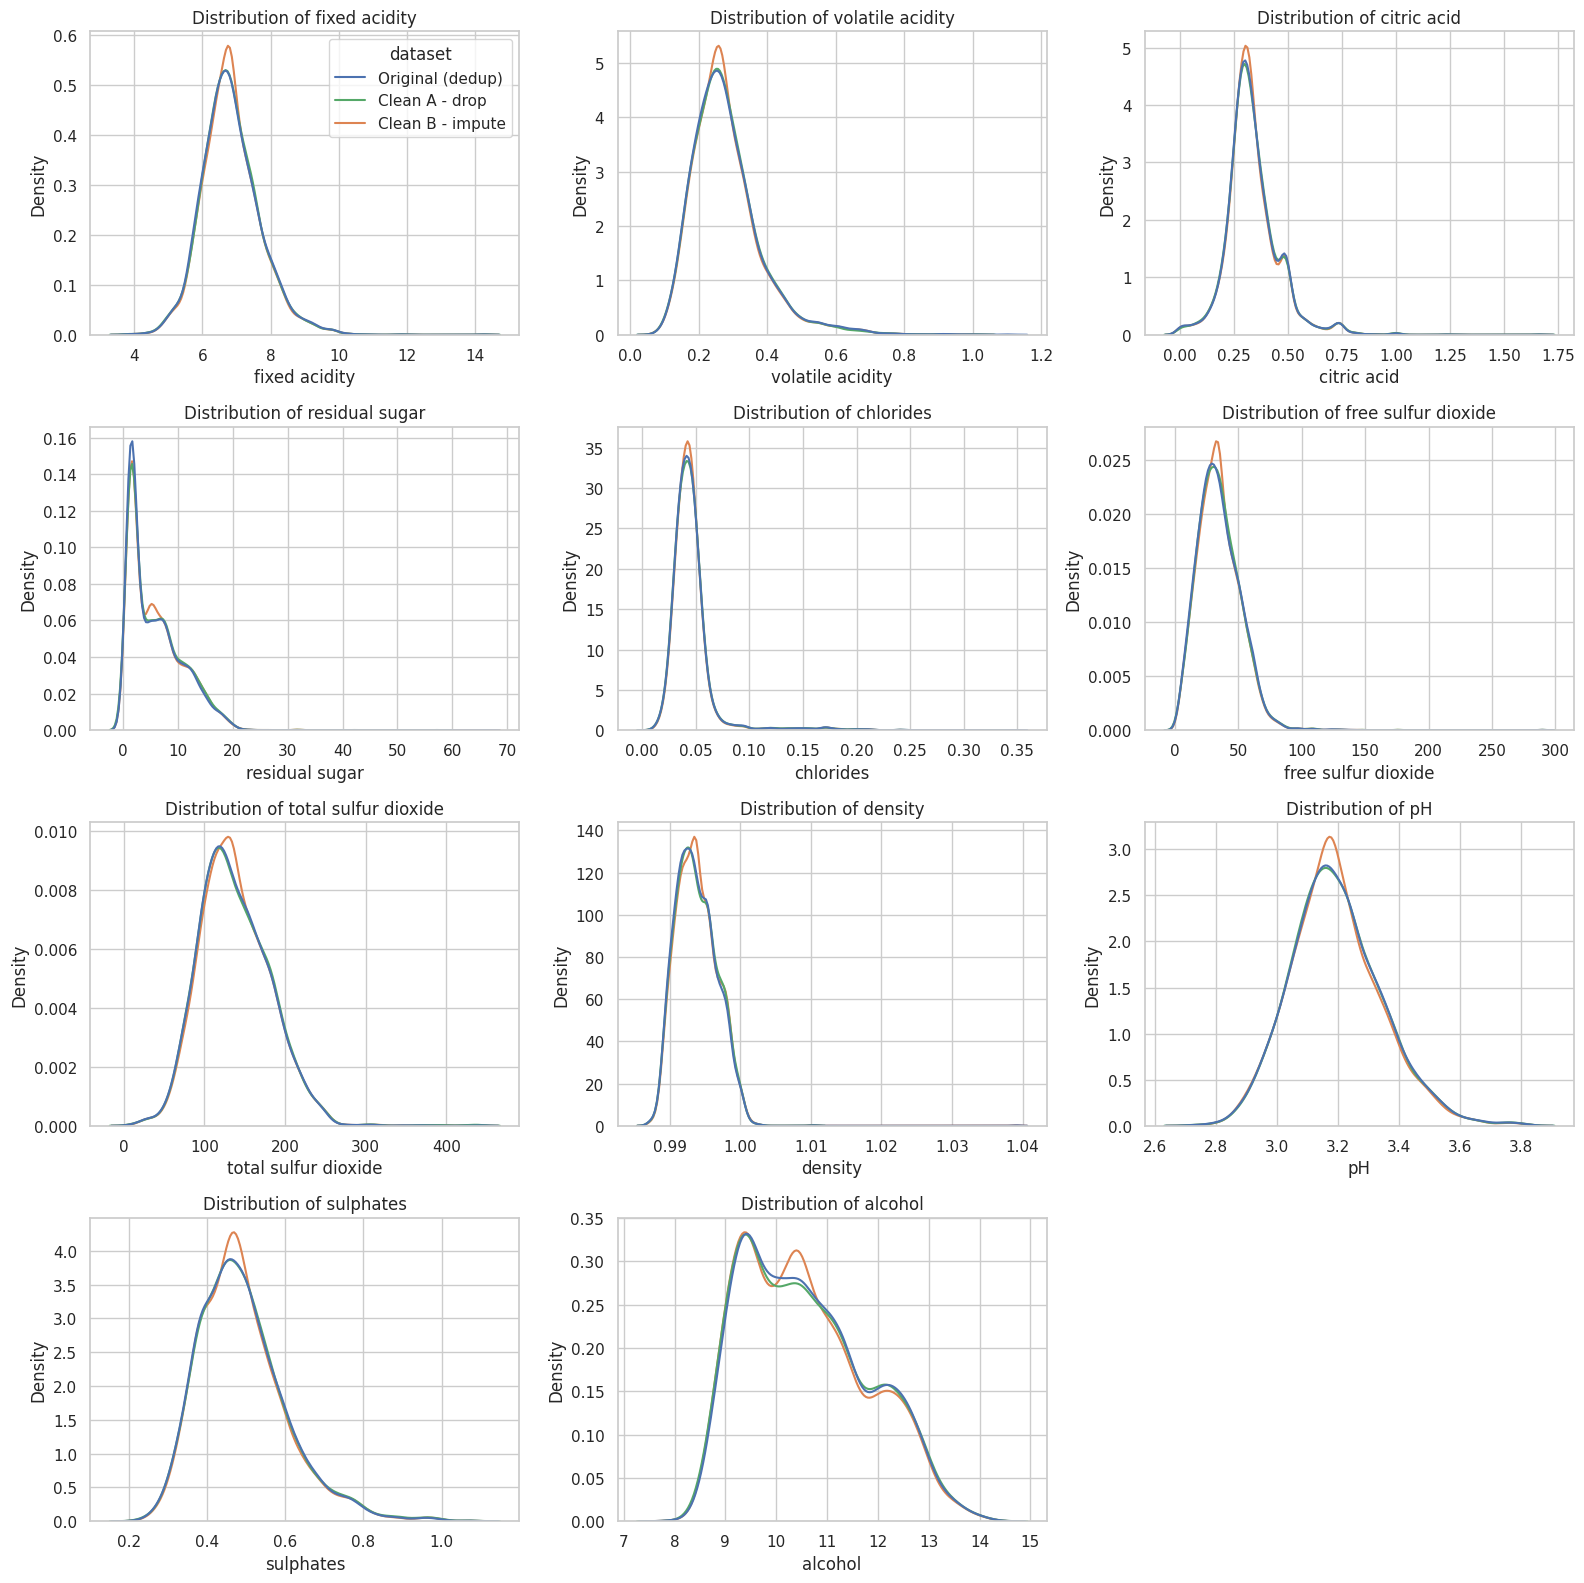

In [80]:
# Distribution overlay: all datasets on the same axes, normalized to density
long_df = long_format(numeric_features)
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for ax, column in zip(axes.flat, numeric_features):
    sns.kdeplot(data=long_df, x=column, hue="dataset", palette=PALETTE,
                common_norm=False, ax=ax, linewidth=1.5, legend=(column == numeric_features[0]))
    ax.set_title(f"Distribution of {column}")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

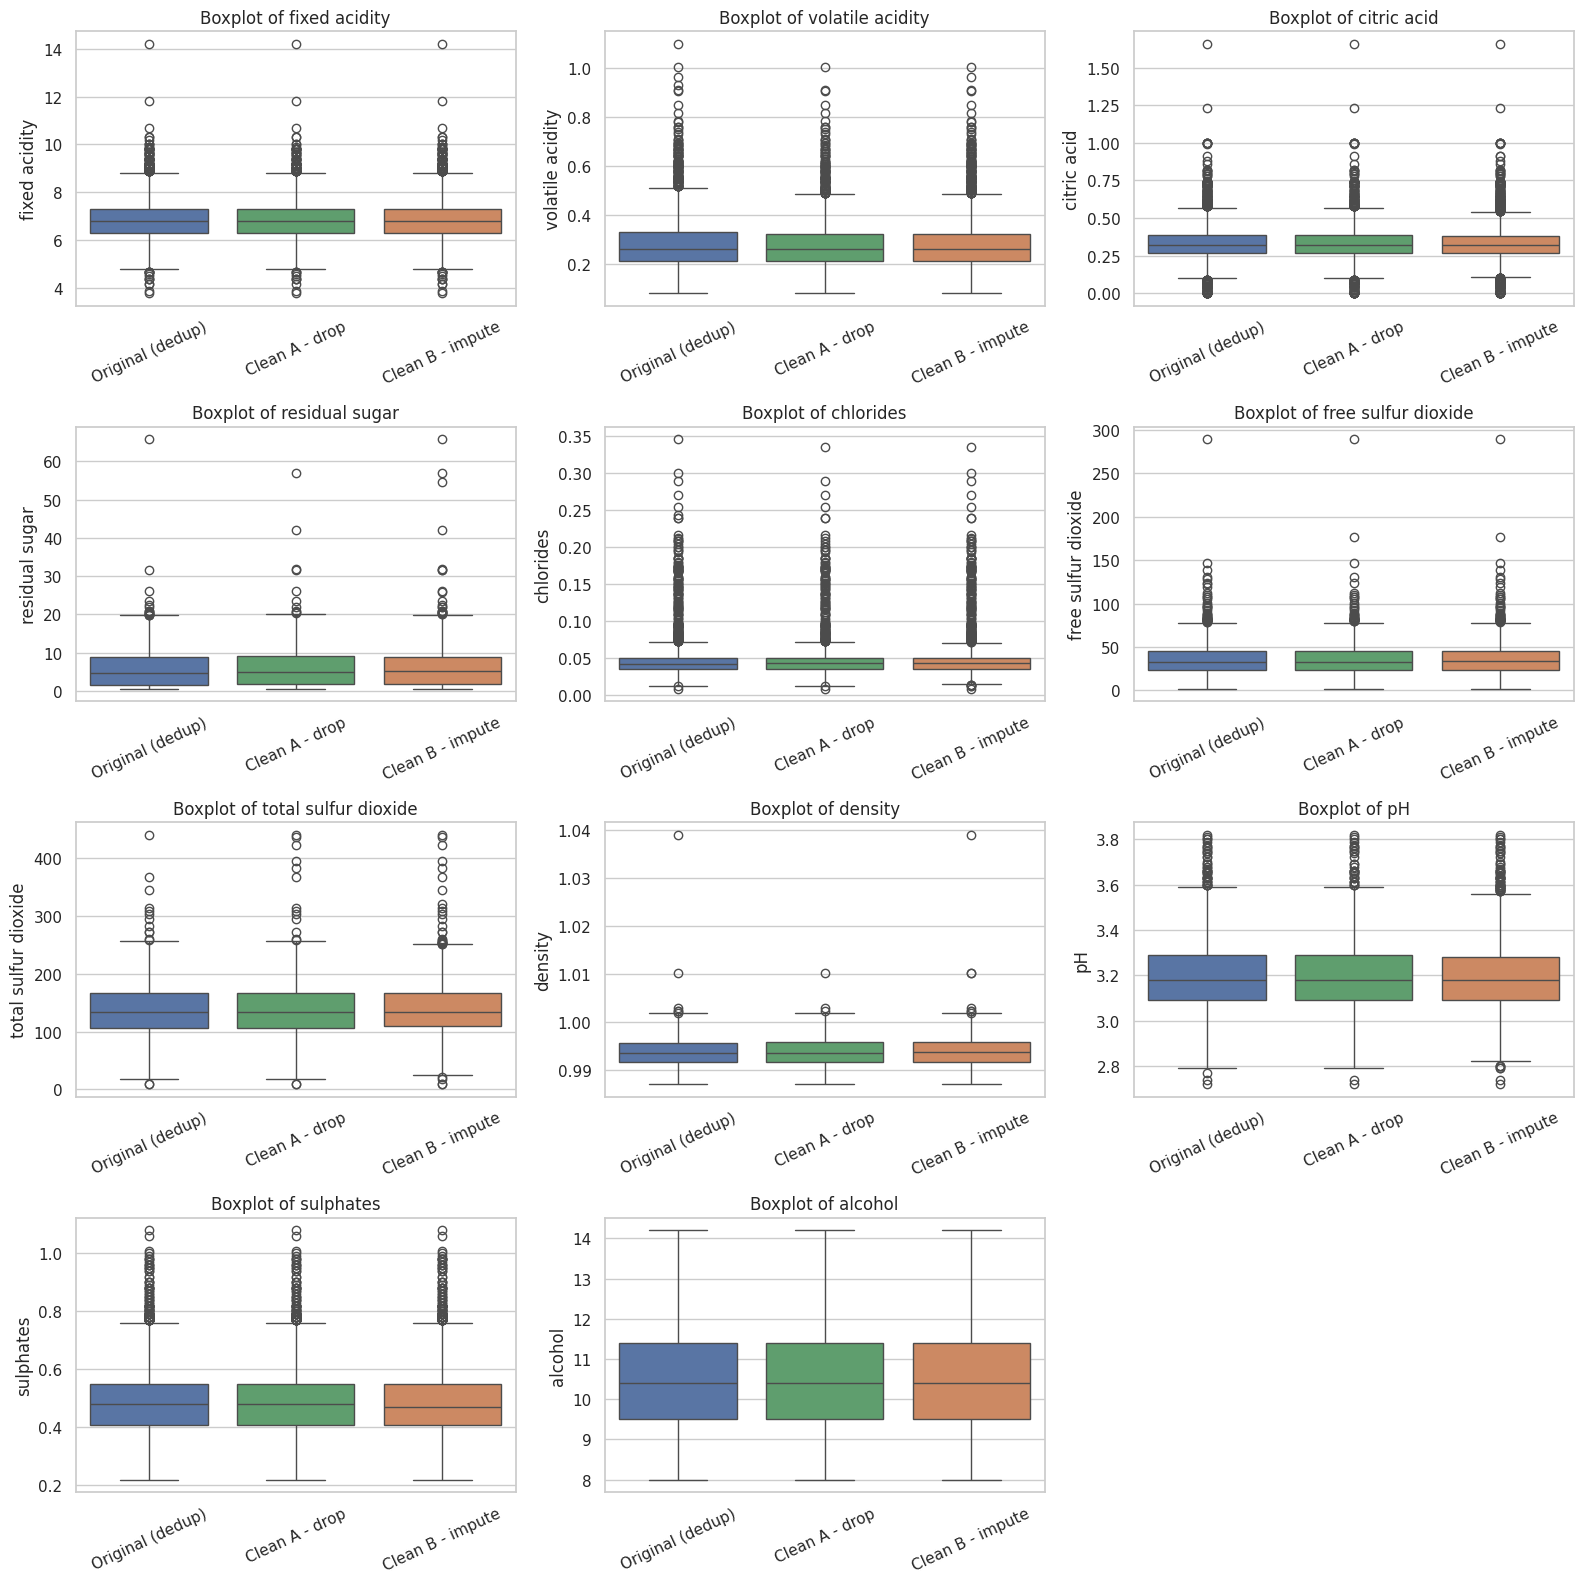

In [81]:
# Boxplots side by side: spread and potential extreme values per dataset
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for ax, column in zip(axes.flat, numeric_features):
    sns.boxplot(data=long_df, x="dataset", y=column, hue="dataset", palette=PALETTE, ax=ax, legend=False)
    ax.set_title(f"Boxplot of {column}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

The curves of the cleaned datasets lie on top of the originals. For Strategy B, look for a slightly taller, sharper peak
at the median in some variables (clearly visible in `alcohol`, `pH` and `sulphates`): that is the visual signature of
median imputation, since about 1–2% of each column was set to the same value.

## 8.4 Potential outliers using the IQR rule

In [82]:
def iqr_outlier_pct(d):
    out = {}
    for column in numeric_features:
        q1, q3 = d[column].quantile([0.25, 0.75])
        iqr = q3 - q1
        out[column] = 100 * ((d[column] < q1 - 1.5 * iqr) | (d[column] > q3 + 1.5 * iqr)).mean()
    return pd.Series(out)

pd.DataFrame({name: iqr_outlier_pct(d) for name, d in datasets.items()}).round(2)

,Original (dedup),Clean A - drop,Clean B - impute
fixed acidity,2.68,2.53,2.54
volatile acidity,3.36,3.93,3.98
citric acid,5.63,5.53,6.74
residual sugar,0.40,0.32,0.49
chlorides,4.49,4.51,4.31
free sulfur dioxide,1.11,1.12,1.08
total sulfur dioxide,0.35,0.48,0.68
density,0.15,0.10,0.16
pH,1.16,1.09,1.53
sulphates,2.42,2.72,2.52


The percentage of *potential* outliers per feature is similar across datasets. This confirms that cleaning removed the
injected **errors** but not the natural tails: genuine unusual wines are still there, as they should be.

## 8.5 Bivariate analysis: predictors vs. wine quality

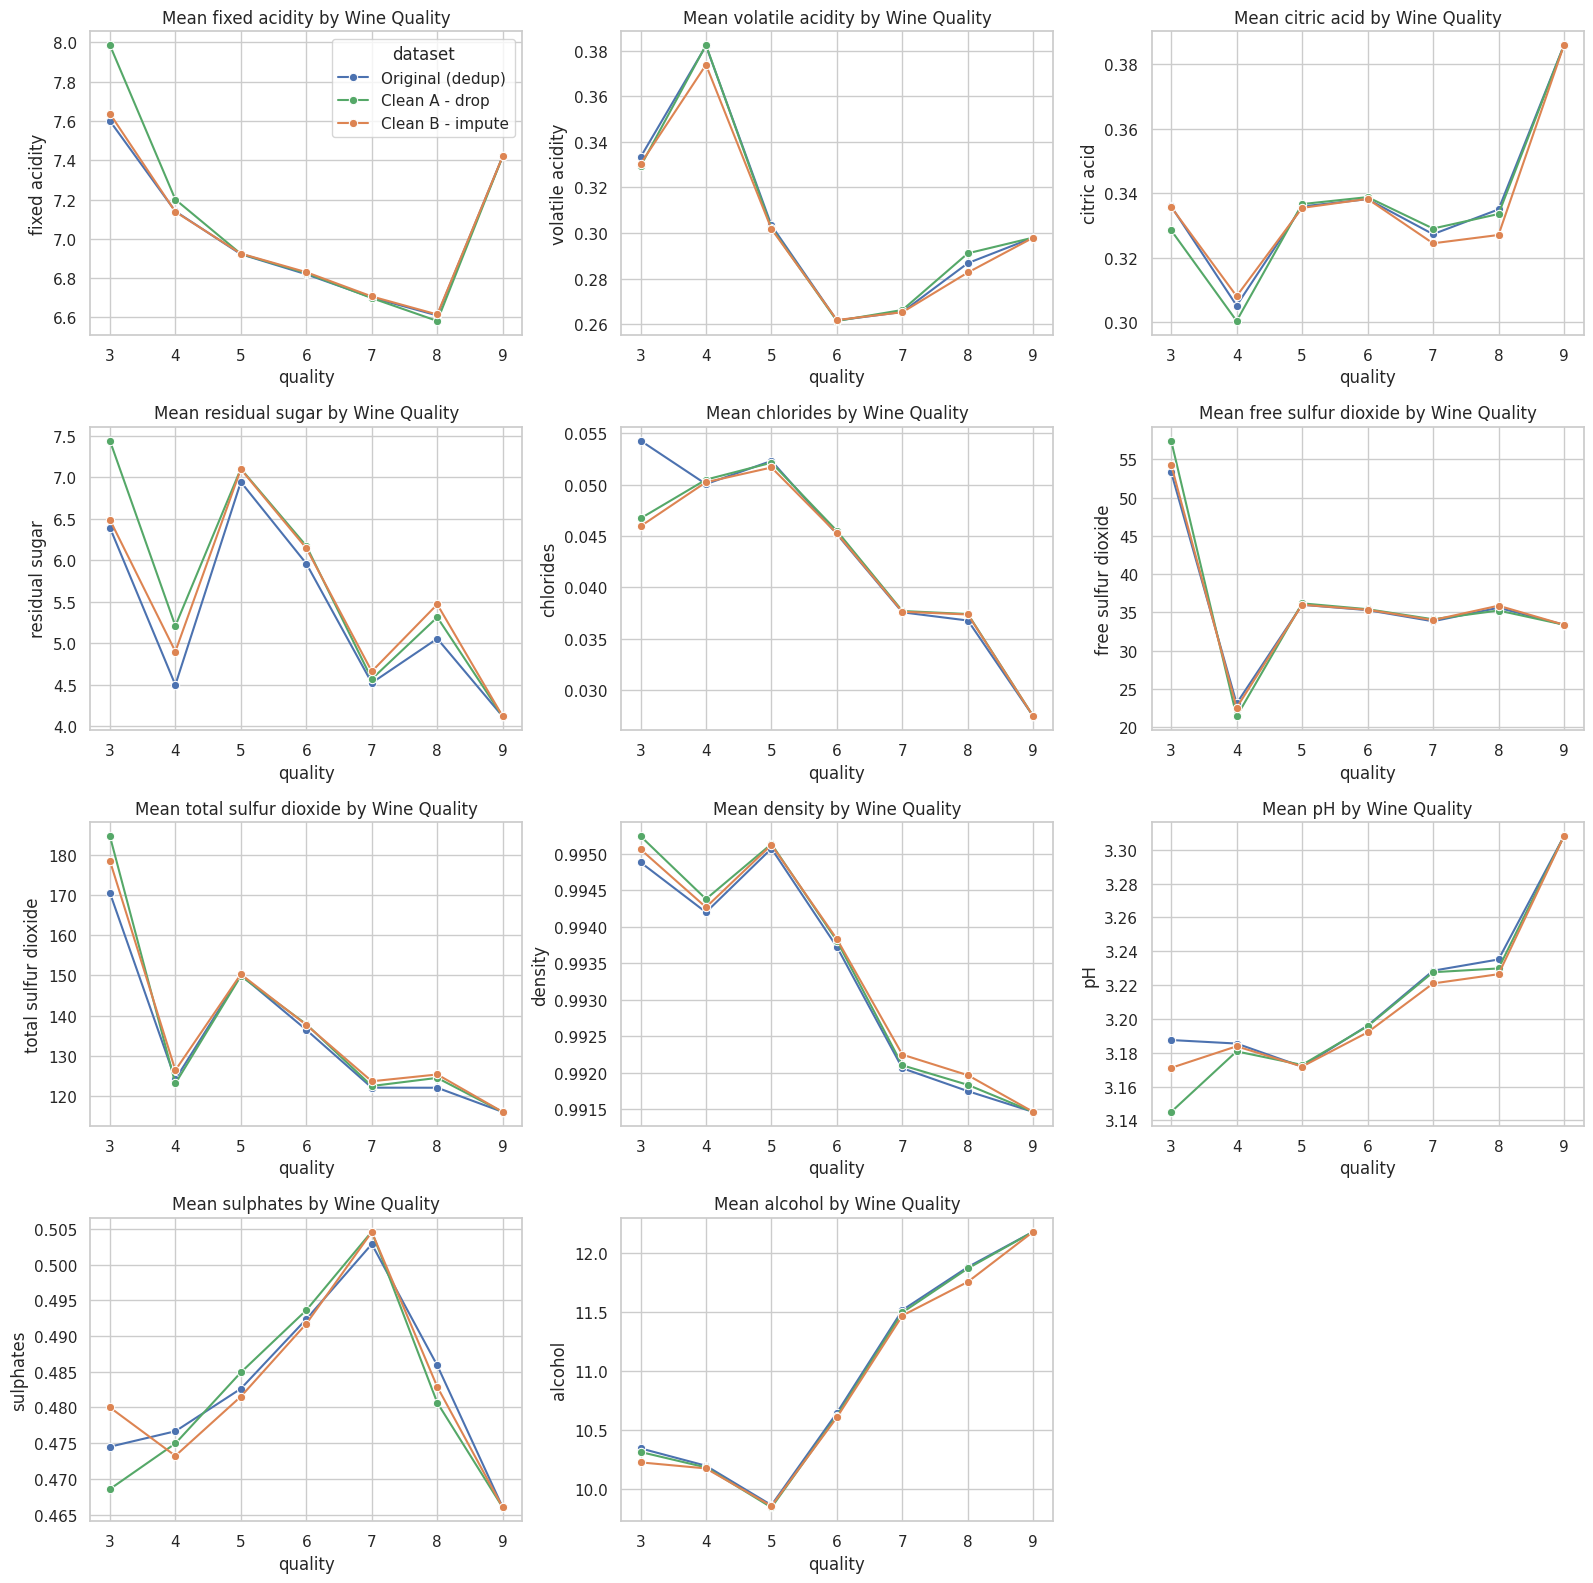

In [83]:
# Mean of each feature by quality level, one line per dataset
means_by_quality = pd.concat(
    [d.groupby(TARGET)[numeric_features].mean().assign(dataset=name).reset_index()
     for name, d in datasets.items()],
    ignore_index=True,
)
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for ax, column in zip(axes.flat, numeric_features):
    sns.lineplot(data=means_by_quality, x=TARGET, y=column, hue="dataset", palette=PALETTE,
                 marker="o", ax=ax, legend=(column == numeric_features[0]))
    ax.set_title(f"Mean {column} by Wine Quality")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

The trends (e.g. alcohol rising with quality, density falling) are preserved. Small deviations appear at quality 3 and 9,
which have very few wines, so every removed row weighs more there.

## 8.6 Correlation analysis (Pearson and Spearman)

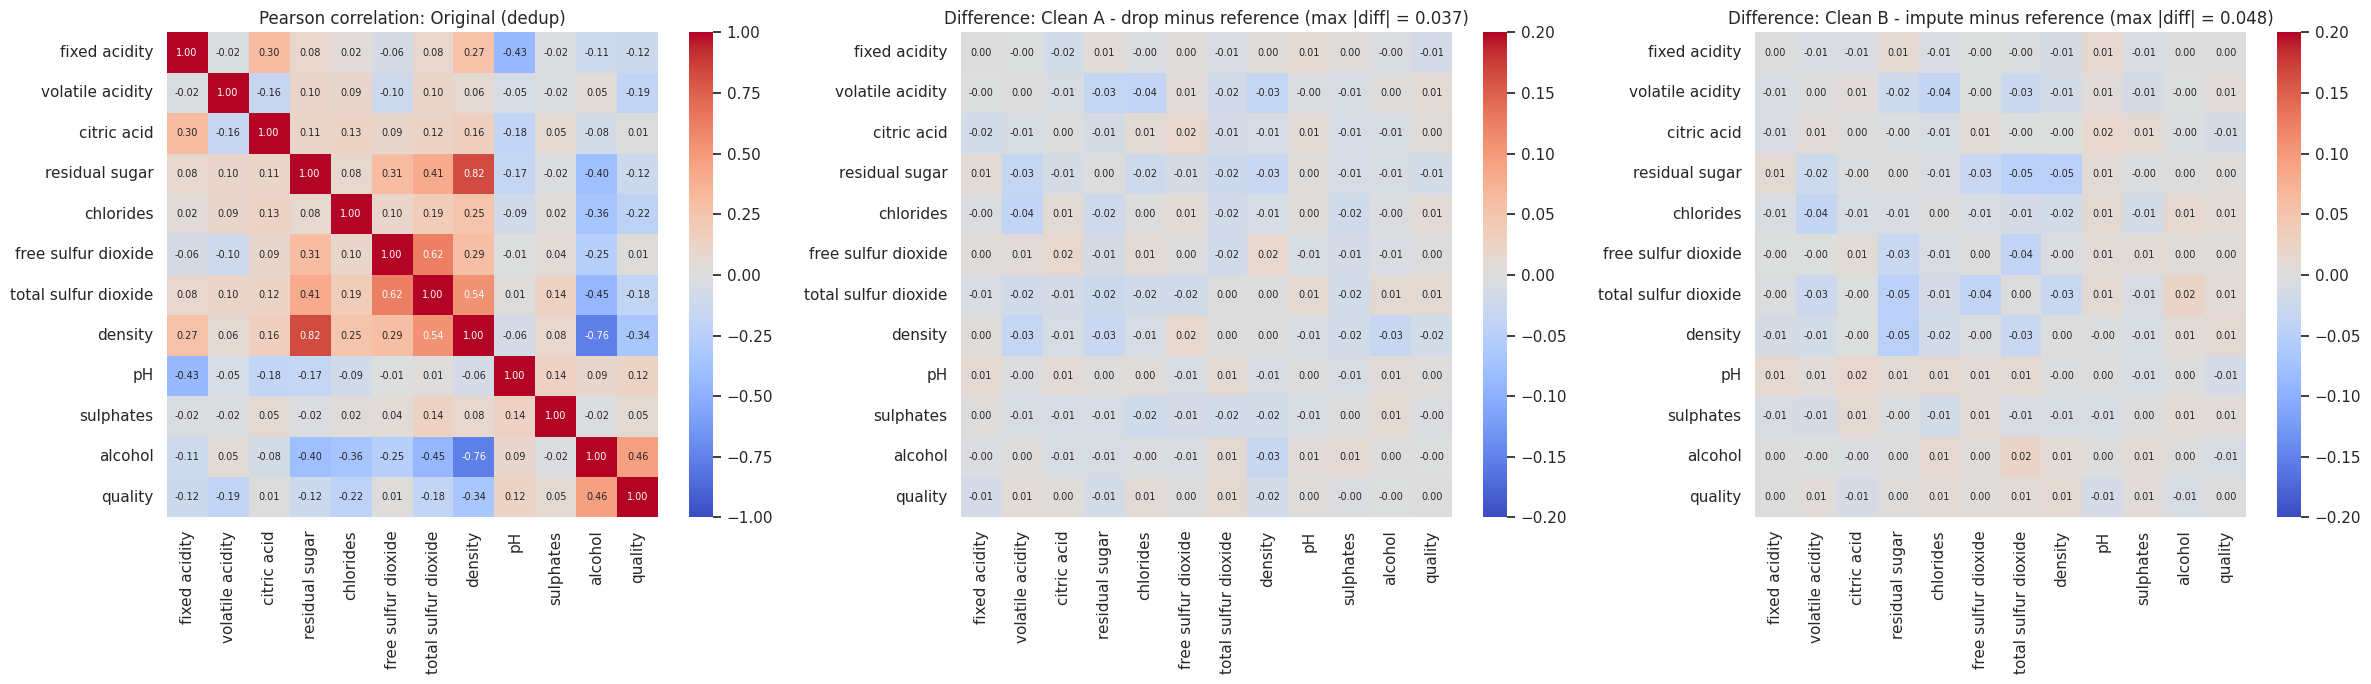

In [84]:
corr_cols = numeric_features + [TARGET]

def corr_diff_heatmaps(method):
    ref = datasets[REFERENCE][corr_cols].corr(method=method)
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    sns.heatmap(ref, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0], annot=True, fmt=".2f", annot_kws={"size": 7})
    axes[0].set_title(f"{method.title()} correlation: {REFERENCE}")
    for ax, name in zip(axes[1:], ["Clean A - drop", "Clean B - impute"]):
        diff = datasets[name][corr_cols].corr(method=method) - ref
        sns.heatmap(diff, cmap="coolwarm", center=0, vmin=-0.2, vmax=0.2, ax=ax, annot=True, fmt=".2f", annot_kws={"size": 7})
        ax.set_title(f"Difference: {name} minus reference (max |diff| = {diff.abs().max().max():.3f})")
    plt.tight_layout()
    plt.show()

corr_diff_heatmaps("pearson")

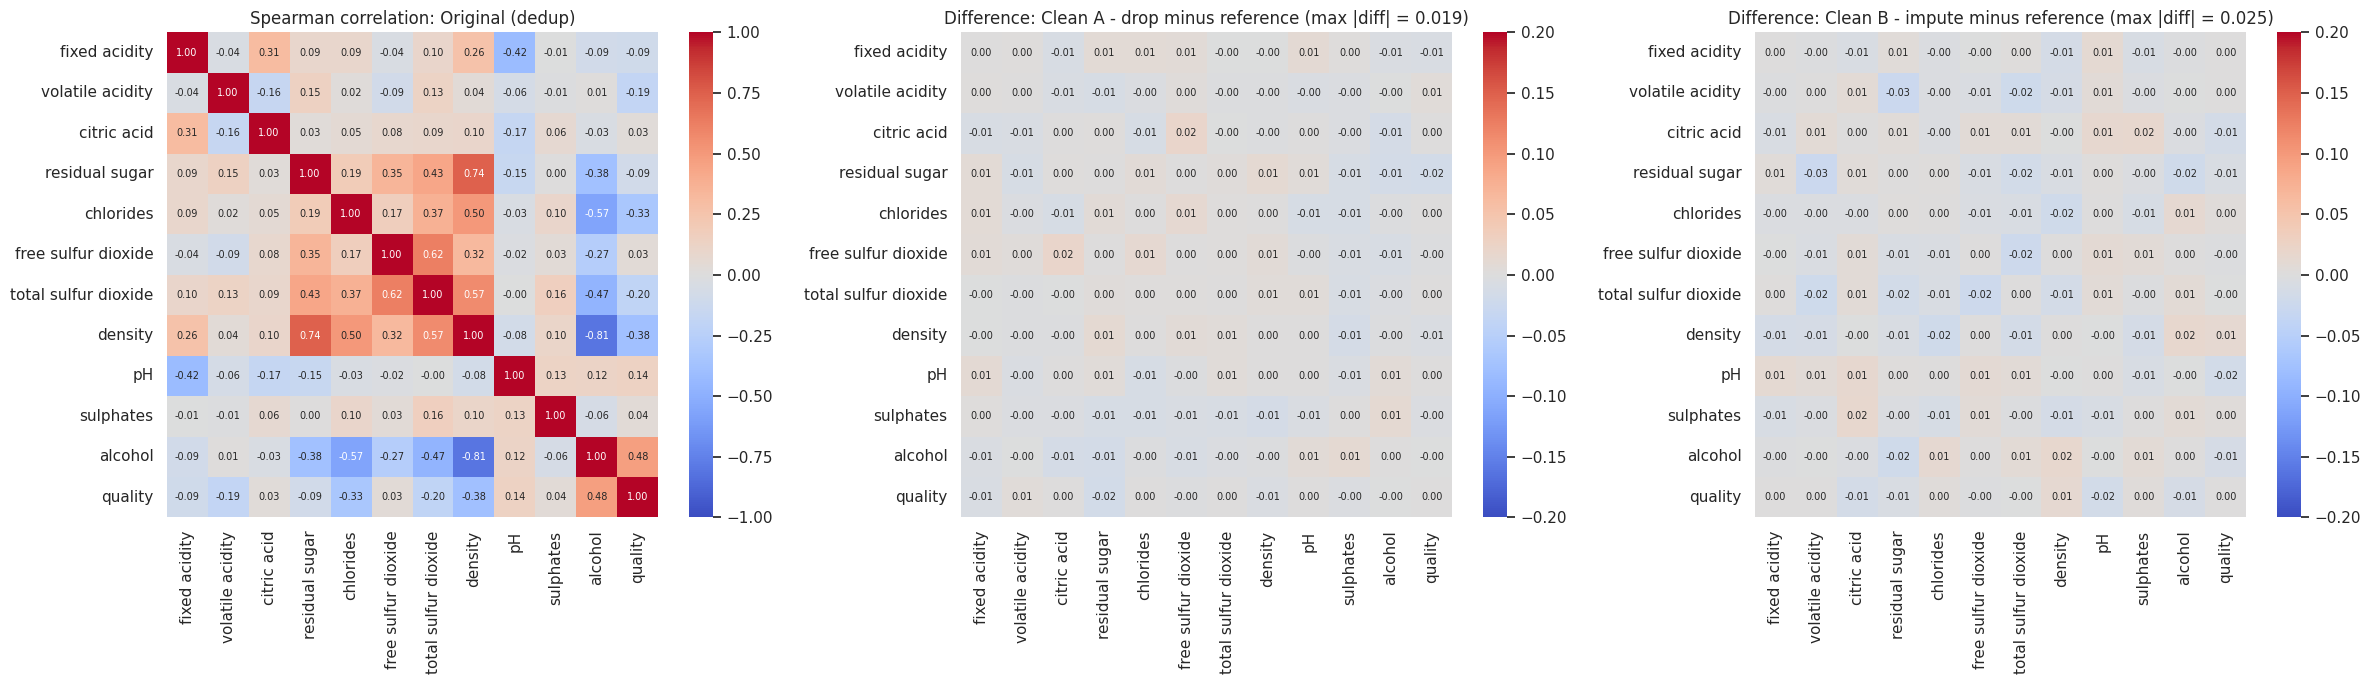

In [85]:
corr_diff_heatmaps("spearman")

The difference heatmaps use a narrow color scale (±0.2) so that small changes become visible. Near-white cells mean the
relationship between two variables is unchanged by cleaning.

In [86]:
# Correlation with quality: the numbers that most often drive feature selection
quality_corr = pd.DataFrame({
    name: d[corr_cols].corr(method="pearson")[TARGET].drop(TARGET) for name, d in datasets.items()
})
quality_corr.sort_values(REFERENCE, key=lambda s: s.abs(), ascending=False).round(3)

,Original (dedup),Clean A - drop,Clean B - impute
alcohol,0.463,0.463,0.454
density,-0.338,-0.354,-0.325
chlorides,-0.218,-0.211,-0.209
volatile acidity,-0.191,-0.181,-0.185
total sulfur dioxide,-0.183,-0.174,-0.175
fixed acidity,-0.125,-0.137,-0.124
pH,0.124,0.126,0.111
residual sugar,-0.117,-0.132,-0.115
sulphates,0.053,0.049,0.059
free sulfur dioxide,0.011,0.012,0.015


In [87]:
# Ranking of features by |correlation with quality|: does cleaning change which features look important?
top_k = 5
rankings = {name: quality_corr[name].abs().sort_values(ascending=False).head(top_k).index.tolist()
            for name in datasets}
pd.DataFrame(rankings, index=[f"#{i + 1}" for i in range(top_k)])

,Original (dedup),Clean A - drop,Clean B - impute
#1,alcohol,alcohol,alcohol
#2,density,density,density
#3,chlorides,chlorides,chlorides
#4,volatile acidity,volatile acidity,volatile acidity
#5,total sulfur dioxide,total sulfur dioxide,total sulfur dioxide


## 8.7 Standardized multivariate profile by quality

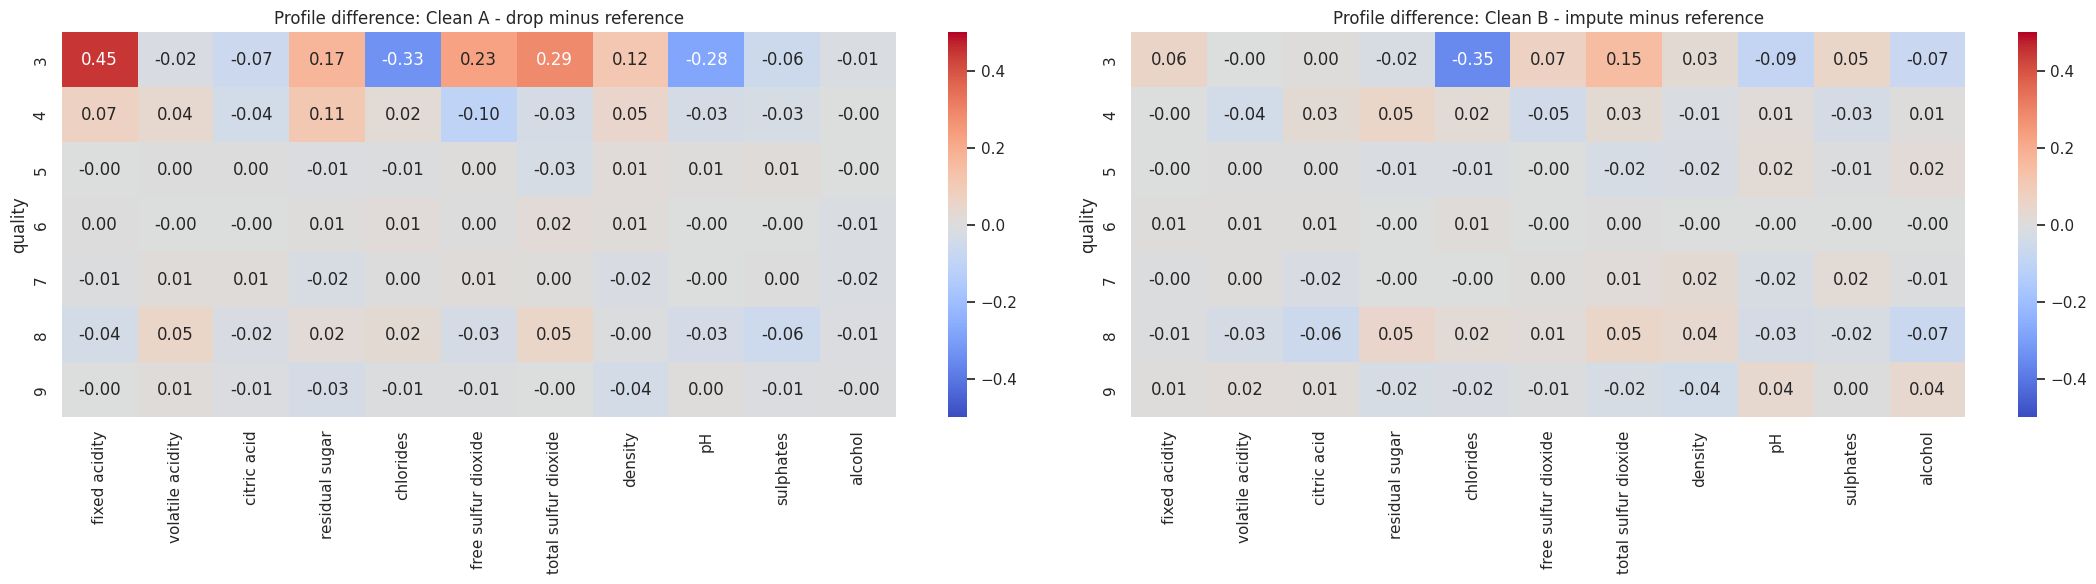

In [88]:
def standardized_profile(d):
    means = d.groupby(TARGET)[numeric_features].mean()
    return (means - d[numeric_features].mean()) / d[numeric_features].std()

ref_profile = standardized_profile(datasets[REFERENCE])
fig, axes = plt.subplots(1, 2, figsize=(22, 6))
for ax, name in zip(axes, ["Clean A - drop", "Clean B - impute"]):
    diff = standardized_profile(datasets[name]) - ref_profile
    sns.heatmap(diff, cmap="coolwarm", center=0, vmin=-0.5, vmax=0.5, annot=True, fmt=".2f", ax=ax)
    ax.set_title(f"Profile difference: {name} minus reference")
plt.tight_layout()
plt.show()

## 8.8 Formal distribution tests

Plots are persuasive but subjective. Three numeric checks make "the distributions correspond" measurable:

| Metric | What it measures | Rule of thumb for "equivalent" |
|---|---|---|
| **Two-sample Kolmogorov–Smirnov (KS)** | Largest gap between the two cumulative distributions | p-value > 0.05 (no evidence of a difference) |
| **Standardized mean difference (SMD)** | Shift of the mean, in reference standard deviations | \|SMD\| < 0.1 is negligible |
| **Variance ratio** | Spread of cleaned / spread of reference | between 0.9 and 1.1 |

> KS on a discrete variable such as `quality` is conservative because of ties; the chi-square test in 8.2 is the proper
> test for the target.

In [89]:
def distribution_tests(name, ref_name=REFERENCE):
    ref, d = datasets[ref_name], datasets[name]
    rows = []
    for column in numeric_features:
        ks = stats.ks_2samp(ref[column], d[column])
        rows.append({
            "feature": column,
            "ks_stat": ks.statistic,
            "ks_pvalue": ks.pvalue,
            "smd": (d[column].mean() - ref[column].mean()) / ref[column].std(),
            "variance_ratio": d[column].var() / ref[column].var(),
        })
    out = pd.DataFrame(rows).set_index("feature")
    out["equivalent"] = (out["ks_pvalue"] > 0.05) & (out["smd"].abs() < 0.1) & out["variance_ratio"].between(0.9, 1.1)
    return out

tests_a = distribution_tests("Clean A - drop")
tests_a.round(4)

,ks_stat,ks_pvalue,smd,variance_ratio,equivalent
feature,,,,,
fixed acidity,0.0066,1.0000,0.0037,0.9921,True
volatile acidity,0.0061,1.0000,-0.0063,0.9441,True
citric acid,0.0056,1.0000,0.0050,1.0194,True
residual sugar,0.0165,0.7170,0.0370,1.0426,True
chlorides,0.0074,1.0000,0.0005,0.9838,True
free sulfur dioxide,0.0087,0.9992,0.0063,1.0065,True
total sulfur dioxide,0.0073,1.0000,0.0139,1.0527,True
density,0.0129,0.9285,0.0190,0.9568,True
pH,0.0030,1.0000,-0.0013,0.9909,True


In [90]:
tests_b = distribution_tests("Clean B - impute")
tests_b.round(4)

,ks_stat,ks_pvalue,smd,variance_ratio,equivalent
feature,,,,,
fixed acidity,0.0199,0.3851,0.0069,0.9583,True
volatile acidity,0.0139,0.8141,-0.0100,0.9407,True
citric acid,0.0169,0.5956,-0.0055,0.9808,True
residual sugar,0.0302,0.0467,0.0388,1.0728,False
chlorides,0.0188,0.4594,-0.0068,0.9373,True
free sulfur dioxide,0.0193,0.4222,0.0037,0.9698,True
total sulfur dioxide,0.0236,0.1991,0.0270,1.0131,True
density,0.0305,0.0435,0.0376,0.9937,False
pH,0.0226,0.2424,-0.0236,0.9617,True


In [91]:
# Scorecard: both cleaned datasets against the deduplicated original
def corr_gap(name, ref_name=REFERENCE):
    return (datasets[name][corr_cols].corr() - datasets[ref_name][corr_cols].corr()).abs().max().max()

scorecard = []
for name in ["Clean A - drop", "Clean B - impute"]:
    t = distribution_tests(name)
    scorecard.append({
        "cleaned": name, "reference": REFERENCE, "rows": len(datasets[name]),
        "features_equivalent": f"{int(t['equivalent'].sum())}/{len(t)}",
        "min_ks_pvalue": t["ks_pvalue"].min(),
        "max_abs_smd": t["smd"].abs().max(),
        "variance_ratio_range": f"{t['variance_ratio'].min():.3f} - {t['variance_ratio'].max():.3f}",
        "max_abs_corr_diff": corr_gap(name),
    })
pd.DataFrame(scorecard).set_index("cleaned").round(4)

,reference,rows,features_equivalent,min_ks_pvalue,max_abs_smd,variance_ratio_range,max_abs_corr_diff
cleaned,,,,,,,
Clean A - drop,Original (dedup),3126,11/11,0.7170,0.0370,0.944 - 1.053,0.0374
Clean B - impute,Original (dedup),4245,9/11,0.0435,0.0388,0.937 - 1.073,0.0475


# 9. Conclusions

**What the tests found and how each was fixed**

| Problem found by | Cleanup action |
|---|---|
| T1 schema | Dropped the noise column `mixed_type_col` |
| T2/T3 types & whitespace | Stripped spaces, cast to numeric explicitly |
| T4/T5 placeholders & missing | Mapped `?`, `n/a`, `error`, `invalid`, `null`, `NaN` to missing |
| T6 domain ranges | Impossible values (10–1000× normal) set to missing |
| T7 consistency | Free SO₂ > total SO₂ → both set to missing |
| T8 target | Rows with invalid `quality` dropped; target cast to integer |
| T9 duplicates | Exact duplicates dropped after normalization |

**Which strategy reproduces the original EDA better?** The scorecard in 8.8 answers it (values from this run):

| vs. Original (dedup), 3,961 rows | Features equivalent | Min KS p-value | Max \|Δcorr\| |
|---|---|---|---|
| **A: drop rows** (3,126 rows) | **11/11** | ≈ 0.72 | ≈ 0.04 |
| **B: impute** (4,245 rows) | 9/11 (`residual sugar`, `density` fail KS narrowly) | ≈ 0.04 | ≈ 0.05 |

- **Strategy A (drop rows)** keeps only genuine measurements, so its distributions, spread and correlations match the
  deduplicated original closely. It costs about a quarter of the rows. That is affordable here because the corruption was random
  (missing completely at random, MCAR) and thousands of rows remain.
- **Strategy B (median imputation)** keeps more rows, but about 1–2% of every column is set to one identical value. The effect
  is visible as sharp peaks in the KDE plots (8.3), and the KS test picks it up for two features. The target distribution, the
  feature ranking by correlation with quality, and the quality profiles are still preserved, so B remains usable when rows are
  scarce, as long as its bias is acknowledged.
- With both strategies, the class balance of `quality` is unchanged (chi-square p > 0.98) and the top-5 features most
  correlated with quality are identical to the original.
- Deduplication itself changes the statistics of the original (e.g. the mean `residual sugar` drops by about 7.5%). That is why
  the baseline was deduplicated with the same rule. Dropping duplicates is a **modelling decision**, not a cleaning error: the
  original contains legitimate repeated measurements, and whichever rule is chosen must be applied consistently to training,
  validation and production data.

**MLOps take-aways**

1. **Test first, then clean.** Every action above is justified by a measured test result.
2. **Write the data contract down** and validate the output against it automatically (Section 6).
3. **Errors ≠ outliers.** Domain rules remove impossible values; statistical rules (IQR) are diagnostics.
4. **Never impute the target**, and fit imputers on the training split only.
5. **Log** every cleaning run (`cleaning_log`) so results are traceable. Here the cleaned CSVs are overwritten on each run;
   in production a data-versioning tool (e.g. DVC) would keep their history.

The baseline `original_no_duplicates.csv` and its full single-dataset EDA come from notebook
`1.3_WineData_EDA_Example.ipynb`.